# Smart Restock: RL Inventory Replenishment on the M5 (Walmart) Dataset

This project showcases reinforcement learning used to train a DQN agent to replenish inventory for a real Walmart product, benchmarking it against a tuned classical (s,S) policy, and stress-testing both under a demand shock.

**Data:** the [M5 Forecasting Accuracy](https://www.kaggle.com/c/m5-forecasting-accuracy) competition dataset. This data is from Walmart, between 2011 and 2016. 

This simulation will use the `gymnasium` package that allows us to make an environment for an agent to take actions with our item stock 

In [1]:
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 3.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 4.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 4.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 2.6 MB/s  0:00:41m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 3.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 3.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 4.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 3.9 M

In [14]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

np.set_printoptions(precision=2, suppress=True)
RNG_SEED = 42

In [15]:
sales = pd.read_csv('m5-forecasting-accuracy/sales_train_evaluation.csv')
calendar = pd.read_csv(f'm5-forecasting-accuracy/calendar.csv')

Here we will go ahead and pick a particular item at a particular store to track. We do not know the names of any specific items in the dataset so we have to refer to them by anonymous names. 

In [16]:
ITEM_ID = 'FOODS_3_090'
STORE_ID = 'CA_1'

In [17]:

row = sales[(sales['item_id'] == ITEM_ID) & (sales['store_id'] == STORE_ID)]
row

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
2314,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,107,182,47,47,...,77,47,74,38,42,39,51,69,67,64


In [18]:
d_cols = [c for c in sales.columns if c.startswith('d_')]
demand_full = row[d_cols].values.flatten().astype(int)

cal = calendar.iloc[:len(demand_full)].copy()
snap_full = cal['snap_CA'].values.astype(int)  # real SNAP-benefit-day indicator for California

print(f'Item {ITEM_ID} at Store {STORE_ID}: {len(demand_full)} days, {cal["date"].iloc[0]} to {cal["date"].iloc[-1]}')
print(f'mean daily demand: {demand_full.mean():.1f}, SNAP days: {snap_full.mean():.1%} of all days')

Item FOODS_3_090 at Store CA_1: 1941 days, 2011-01-29 to 2016-05-22
mean daily demand: 66.4, SNAP days: 33.0% of all days


train: 1552 days (mean=70.6)
test:  389 days (mean=49.7) -- chronologically held out


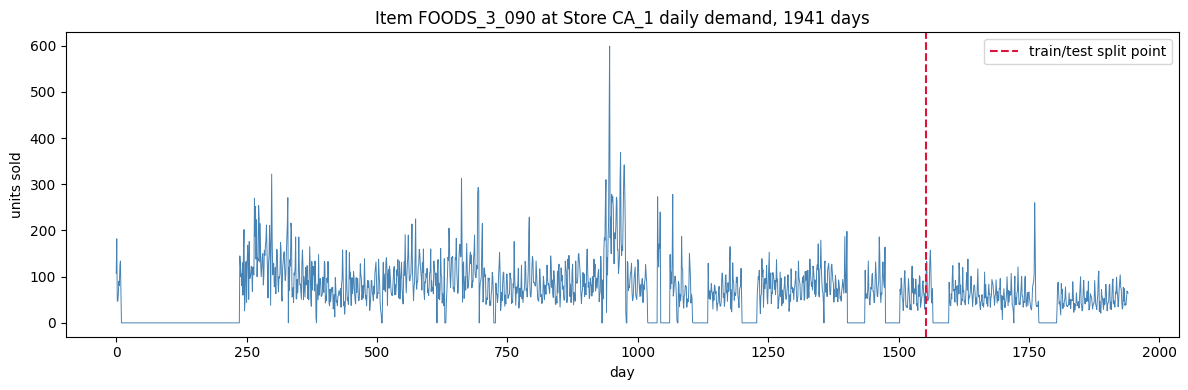

In [19]:
split_idx = int(len(demand_full) * 0.8)
# chronologically split the data
train_demand, test_demand = demand_full[:split_idx], demand_full[split_idx:]
train_snap, test_snap = snap_full[:split_idx], snap_full[split_idx:]

print(f'train: {len(train_demand)} days (mean={train_demand.mean():.1f})')
print(f'test:  {len(test_demand)} days (mean={test_demand.mean():.1f}) -- chronologically held out')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(demand_full, color='steelblue', linewidth=0.7)
# Mark the cutoff between train and test data
ax.axvline(split_idx, color='crimson', linestyle='--', label='train/test split point') 
ax.set_xlabel('day'); ax.set_ylabel('units sold')
ax.set_title(f'Item {ITEM_ID} at Store {STORE_ID} daily demand, {len(demand_full)} days')
ax.legend(); plt.tight_layout(); plt.show()

In [20]:
# Parameters for the inventory restocking simulation
ORDER_STEP = 5 
N_ACTIONS = 25  

When 'ORDER_STEP' = 5, and 'N_ACTIONS' = 25, the possible order quantities are: 0, 5, 10, ..., 120  Every 5 units of order quantity is a discrete action, and the maximum order quantity is 120 units. Essentially the agent can order 5 units in a single action.

We will need to make a custom environment for our inventory tracking and for actions to be taken on that. We will build the custom environment based on the gymnasium package environment structure. This means we need the following:
- An observation space
- An action space
- A reset() method 
- A step() method

In [ ]:
class InventoryEnv(gym.Env):
    """Create a reinforcement-learning environment for inventory replenishment.

    The environment simulates a store deciding how much inventory to order each day
    while balancing holding costs, stockout penalties, and ordering costs.
    """

    metadata = {'render_modes': []}

    def __init__(self, demand_series=None, snap_series=None, episode_sampler=None, lead_time=2, order_step=ORDER_STEP, n_actions=N_ACTIONS,
                 max_inventory=250, holding_cost=0.08, stockout_penalty=1.2,
                 fixed_order_cost=10.0, variable_order_cost=0.4,
                 history_window=7, reward_scale=20.0):
        """
        Args:
            demand_series (np.ndarray | None): Fixed demand history used for evaluation.
            snap_series (np.ndarray | None): SNAP-day indicator series aligned with demand.
            episode_sampler (callable | None): Optional function that generates randomized training episodes.
            lead_time (int): Number of days before an order arrives.
            order_step (int): Size of each discrete order increment.
            n_actions (int): Number of discrete actions available to the agent.
            max_inventory (int): Maximum inventory level the environment allows.
            holding_cost (float): Daily cost per unit of held inventory.
            stockout_penalty (float): Cost incurred for each unmet unit of demand.
            fixed_order_cost (float): Cost charged when any order is placed.
            variable_order_cost (float): Per-unit cost of ordering.
            history_window (int): Number of recent demand values included in the observation.
            reward_scale (float): Scaling factor applied to rewards for training stability.
        """
        super().__init__()

        # optional function allows training episodes to be generated from random windows of historical demand instead of always using one fixed sequence.
        self.episode_sampler = episode_sampler
        # If demand_series is provided, snap_series must also be provided. If episode_sampler is provided, demand_series and snap_series are ignored.
        # demand_series and snap_series are used for evaluation, while episode_sampler is used for training on randomly windowed and jittered slices of a longer historical series.
        self._set_episode(demand_series if demand_series is not None else np.zeros(1), snap_series)

        self.lead_time = lead_time 
        self.order_step = order_step 
        self.max_inventory = max_inventory
        self.holding_cost = holding_cost
        self.stockout_penalty = stockout_penalty
        self.fixed_order_cost = fixed_order_cost
        self.variable_order_cost = variable_order_cost
        self.history_window = history_window
        self.reward_scale = reward_scale  # keeps DQN's target values in a stable range
        self.action_space = spaces.Discrete(n_actions)
        
        obs_dim = 1 + lead_time + history_window + 2  # + day_of_week + snap_today
        self.observation_space = spaces.Box(low=0, high=max(max_inventory, 1000), shape=(obs_dim,), dtype=np.float32)
        
        self.t = 0 # t is the current day index in the simulation, starting at 0 for the first day of the episode.

    def _set_episode(self, demand_series, snap_series):
        """Set the demand history for the active episode.

        Args:
            demand_series (np.ndarray): Demand values for the episode.
            snap_series (np.ndarray | None): SNAP-day indicators aligned with the demand history.

        Returns:
            None
        """
        self.demand_series = demand_series
        self.snap_series = snap_series if snap_series is not None else np.zeros(len(demand_series))
        self.n_periods = len(demand_series)

    def _get_obs(self):
        """Build the observation vector for the current time step.

        Returns:
            np.ndarray: The current state containing inventory, pending orders,
            recent demand, weekday, and SNAP indicator.
        """
        day_of_week = self.t % 7
        snap_today = self.snap_series[self.t] if self.t < len(self.snap_series) else 0
        return np.concatenate([
            [self.inventory], self.pipeline, self.recent_demand, [day_of_week], [snap_today],
        ]).astype(np.float32)

    def reset(self, seed=None, options=None):
        """Reset the environment to start a fresh episode.

        Args:
            seed (int | None): Optional random seed for reproducibility.
            options (dict | None): Optional reset options.

        Returns:
            tuple[np.ndarray, dict]: The initial observation and an empty info dictionary.
        """
        super().reset(seed=seed)
        if self.episode_sampler is not None:
            demand, snap = self.episode_sampler(self.np_random)
            self._set_episode(demand, snap)

        self.t = 0
        self.inventory = self.max_inventory // 4
        self.pipeline = np.zeros(self.lead_time, dtype=np.float32)
        self.recent_demand = np.zeros(self.history_window, dtype=np.float32)
        return self._get_obs(), {}

    def step(self, action):
        """Advance the environment by one day using the agent's chosen action.

        Args:
            action (int): Discrete action index representing the order quantity.

        Returns:
            tuple[np.ndarray, float, bool, bool, dict]: The next observation, reward,
            termination flag, truncation flag, and diagnostic information.
        """
        order_qty = int(action) * self.order_step
        arriving = self.pipeline[0]
        demand = self.demand_series[self.t]
        available = self.inventory + arriving
        served = min(available, demand)
        unmet = demand - served
        next_inventory = min(available - served, self.max_inventory)

        cost = (self.holding_cost * next_inventory + self.stockout_penalty * unmet
                + (self.fixed_order_cost if order_qty > 0 else 0.0) + self.variable_order_cost * order_qty)
        reward = -cost / self.reward_scale  # scaled for training; true cost kept in info

        self.pipeline = np.roll(self.pipeline, -1)
        self.pipeline[-1] = order_qty
        self.inventory = next_inventory
        self.recent_demand = np.roll(self.recent_demand, -1)
        self.recent_demand[-1] = demand
        self.t += 1 

        terminated = self.t >= self.n_periods
        info = {'demand': demand, 'unmet': unmet, 'order_qty': order_qty, 'cost': cost}
        return self._get_obs(), reward, terminated, False, info


def make_windowed_sampler(full_demand, full_snap, episode_length=120, jitter_std=0.08):
    """Create a sampler for randomized training episodes.

    Args:
        full_demand (np.ndarray): Full historical demand series.
        full_snap (np.ndarray): Full SNAP-day indicator series aligned with demand.
        episode_length (int): Number of days in each sampled episode.
        jitter_std (float): Standard deviation of the random demand jitter applied to each episode.

    Returns:
        callable: A function that samples one windowed, jittered episode when given an RNG.
    """
    def sample(rng):
        """Sample one training episode from the historical series.

        Args:
            rng (np.random.Generator): Random number generator used to choose the episode window.

        Returns:
            tuple[np.ndarray, np.ndarray]: A jittered demand window and matching SNAP series.
        """
        start = rng.integers(0, len(full_demand) - episode_length)
        window = full_demand[start:start + episode_length].astype(float)
        jitter = rng.normal(1.0, jitter_std, size=window.shape)
        window = np.clip(window * jitter, 0, None).round().astype(int)
        snap = full_snap[start:start + episode_length]
        return window, snap
    return sample

We will start by comparing to a continuous review policy. This is often denoted as (s, S), where the lowercase "s" is the point at which we need to order things to replenish supply and uppercase "S" is the target inventory we want to replenish to when we do restock. 

In [ ]:
def run_sS_episode(s, S, demand_series, snap_series=None, env_kwargs=None):
    """Evaluate one (s, S) inventory policy over a demand history.
    
    Args:
        s (int): Reorder point. If current inventory is below this value, the policy orders.
        S (int): Target inventory position to reach when ordering.
        demand_series (np.ndarray): Demand history used to simulate the episode.
        snap_series (np.ndarray | None): Optional SNAP-day indicator values aligned with demand.
        env_kwargs (dict | None): Extra keyword arguments passed to InventoryEnv.
    
    Returns:
        tuple[float, float]: Total simulation cost and stockout rate for the episode.
    """
    env_kwargs = env_kwargs or {}
    env = InventoryEnv(demand_series, snap_series, **env_kwargs)
    obs, _ = env.reset()

    total_cost, total_demand, total_unmet = 0.0, 0, 0
    terminated = False

    # Simulate the inventory policy day by day until the episode ends.
    while not terminated:
        # Track the current stock position including orders already in transit.
        position = env.inventory + env.pipeline.sum()

        # If inventory is below the reorder point, order enough to reach S.
        raw_target = S if position < s else position
        order_qty = max(0, raw_target - position)

        # Convert the desired order quantity into a discrete action supported by the environment.
        action = min(int(round(order_qty / env.order_step)), env.action_space.n - 1)

        # Apply the action and collect the resulting cost details.
        obs, reward, terminated, truncated, info = env.step(action)
        total_cost += info['cost']
        total_demand += info['demand']
        total_unmet += info['unmet']

    return total_cost, total_unmet / max(total_demand, 1)

best = None

# Search over a grid of (s, S) values to find the lowest-cost policy on training data.
for s in range(0, 150, 10):
    for S in range(s + 10, 250, 10):
        cost, stockout = run_sS_episode(s, S, train_demand, train_snap)
        if best is None or cost < best[2]:
            best = (s, S, cost, stockout)

best_s, best_big_s = best[0], best[1]

# Report the best policy found during training and evaluate it on the held-out test set.
print(f'Best (s,S) on training data: s={best_s}, S={best_big_s}  (train cost={best[2]:.2f})')

baseline_cost, baseline_stockout = run_sS_episode(best_s, best_big_s, test_demand, test_snap)
print(f'Baseline on HELD-OUT test: cost={baseline_cost:.0f}, stockout_rate={baseline_stockout:.1%}')

Best (s,S) on training data: s=140, S=230  (train cost=89536.00)
Baseline on HELD-OUT test: cost=13793, stockout_rate=16.1%
